In [ ]:
!pip install -U "numpy<2.0" tensorflow==2.16.2 ml-dtypes==0.3.2 albumentations geotile fiona

In [ ]:
!pip uninstall -y jax jaxlib

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Conv2DTranspose,
    Concatenate,
    Dropout
)

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
import os
os.chdir(r'/content/gdrive/MyDrive/Course Geoai/After')

In [ ]:
train_xx_initial = np.load('x_train.npy')
train_yy_initial = np.load('y_train.npy')
test_xx = np.load('x_test.npy')
test_yy = np.load("y_test.npy")
print(train_xx_initial.shape, train_yy_initial.shape, test_xx.shape, test_yy.shape)

(256, 256, 256, 3) (256, 256, 256, 1) (256, 256, 256, 3) (256, 256, 256, 1)


## Augmentasi Data

In [ ]:
import albumentations as A
import numpy as np

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=45, p=0.5),
    A.Affine(scale=(0.5, 1.5), p=0.5),
    A.Affine(translate_percent=(-0.2, 0.2), p=0.5),
])

In [ ]:
augmented_images = []
augmented_masks = []

num_augmentations = 3

for i in range(train_xx_initial.shape[0]):
    image = train_xx_initial[i]
    mask  = train_yy_initial[i].astype(np.int32)

    for _ in range(num_augmentations):
        augmented = transform(image=image, mask=mask)

        augmented_images.append(augmented["image"])
        augmented_masks.append(augmented["mask"])

In [ ]:
augmented_images = np.array(augmented_images)
augmented_masks  = np.array(augmented_masks)

In [ ]:
# append augmented images/masks with original images/masks
train_xx = np.concatenate((train_xx_initial, augmented_images), axis=0)
train_yy = np.concatenate((train_yy_initial, augmented_masks), axis=0)

In [ ]:
# release memory
del augmented_images
del augmented_masks

In [ ]:
train_xx.max(), train_xx.min(), train_xx.dtype

(1.0, 0.0, dtype('float32'))

In [ ]:
train_xx.shape, train_yy.shape

((1024, 256, 256, 3), (1024, 256, 256, 1))

In [ ]:
num_samples = train_xx.shape[0]
shuffled_indices = np.random.permutation(num_samples)

train_xx = train_xx[shuffled_indices]
train_yy = train_yy[shuffled_indices]

1003


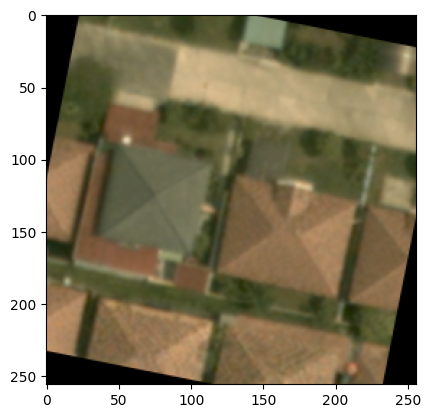

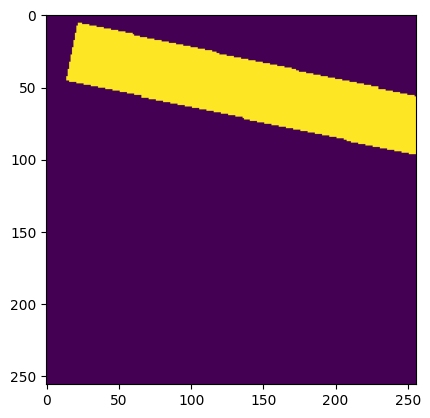

In [ ]:
img = np.random.randint(0, 1024)
print(img)
plt.imshow(train_xx[img, :, :, :3])
plt.show()
plt.imshow(train_yy[img, :, :, 0])
plt.show()

## Arsitektur Unet

In [ ]:
x_in = Input(shape=(256, 256, 3))

'''Encoder'''
x_temp = Conv2D(32, (3, 3), activation='relu', padding='same')(x_in)
x_temp = Dropout(0.25)(x_temp)
x_skip1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = MaxPooling2D((2,2))(x_skip1)
x_temp = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = Dropout(0.25)(x_temp)
x_skip2 = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = MaxPooling2D((2,2))(x_skip2)
x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = Dropout(0.25)(x_temp)
x_skip3 = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = MaxPooling2D((2,2))(x_skip3)
x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = Dropout(0.5)(x_temp)
x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)

'''Decoder'''
x_temp = Conv2DTranspose(64, (3, 3), activation='relu',  padding='same')(x_temp)
x_temp = Dropout(0.5)(x_temp)
x_temp = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu',  padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip3])
x_temp = Conv2DTranspose(64, (3, 3), activation='relu',  padding='same')(x_temp)
x_temp = Dropout(0.5)(x_temp)
x_temp = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu',  padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip2])
x_temp = Conv2DTranspose(32, (3, 3), activation='relu',  padding='same')(x_temp)
x_temp = Dropout(0.5)(x_temp)
x_temp = Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu',  padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip1])
x_temp = Conv2DTranspose(32, (3, 3), activation='relu',  padding='same')(x_temp)
x_temp = Dropout(0.5)(x_temp)
x_temp = Conv2DTranspose(32, (3, 3), activation='relu',  padding='same')(x_temp)

'''Use 1 by 1 Convolution to get desired output bands'''
x_temp = Conv2D(32, (1, 1), activation='relu', padding='same')(x_temp)
x_temp = Conv2D(32, (1, 1), activation='relu', padding='same')(x_temp)
x_out = Conv2D(1, (1, 1), activation='sigmoid', padding='same')(x_temp)
# use sigmoid activation here because output values are either 0 or 1

model = Model(inputs=x_in, outputs=x_out)

model.compile(loss='binary_crossentropy', optimizer='adam')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     36,928 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     36,928 │ dropout_3[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │     36,928 │ conv2d_7[0][0]  

 Total params: 409,281 (1.56 MB)

 Trainable params: 409,281 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training model
import tensorflow as tf

# callback function to stop overfitting the model
checkpointer = tf.keras.callbacks.ModelCheckpoint("best_weight.h5", monitor="val_loss", verbose=1, save_best_only=True, mode="min")
earlyStopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, verbose=1, mode='min',restore_best_weights=True)

callbacks = [
    earlyStopping,
    checkpointer
    ]
history = model.fit(train_xx, train_yy,
                    validation_data=(test_xx, test_yy),
                    epochs=10,
                    batch_size=8,
                    verbose=1,
                    callbacks=callbacks)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.4104
Epoch 1: val_loss improved from inf to 0.20177, saving model to best_weight.h5


128/128 ━━━━━━━━━━━━━━━━━━━━ 735s 6s/step - loss: 0.4094 - val_loss: 0.2018
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.1791
Epoch 2: val_loss improved from 0.20177 to 0.18961, saving model to best_weight.h5


128/128 ━━━━━━━━━━━━━━━━━━━━ 751s 6s/step - loss: 0.1791 - val_loss: 0.1896
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.1643
Epoch 3: val_loss improved from 0.18961 to 0.16250, saving model to best_weight.h5


128/128 ━━━━━━━━━━━━━━━━━━━━ 752s 6s/step - loss: 0.1643 - val_loss: 0.1625
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.1482
Epoch 4: val_loss did not improve from 0.16250
128/128 ━━━━━━━━━━━━━━━━━━━━ 740s 6s/step - loss: 0.1482 - val_loss: 0.1676
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 0.1502
Epoch 5: val_loss did not improve from 0.16250
128/128 ━━━━━━━━━━━━━━━━━━━━ 711s 6s/step - loss: 0.1502 - val_loss: 0.1797
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


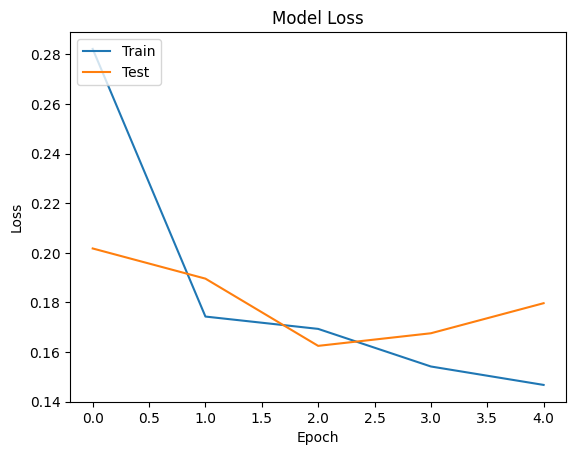

In [ ]:
# plot model loss over training and validation data
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Prediksi

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/gdrive/MyDrive/Course Geoai/After/best_weight.h5")

In [ ]:
threshold = 0.3

pred_test = model.predict(test_xx)
pred_test = (pred_test > threshold).astype(np.uint8)
print(pred_test.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 47s 6s/step
(256, 256, 256, 1)


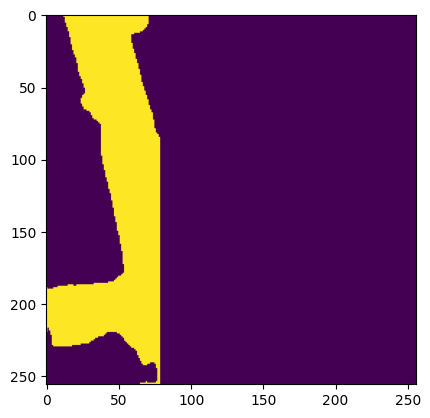

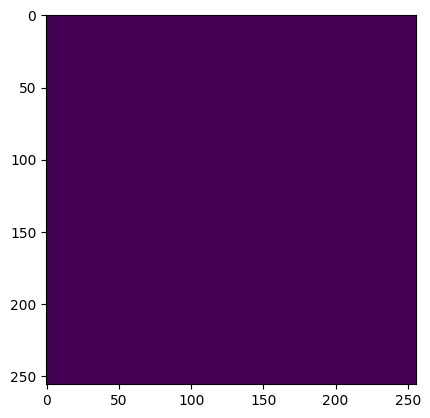

In [ ]:
img = np.random.randint(0, 256)
plt.imshow(pred_test[img, :, :, 0])
plt.show()
plt.imshow(test_yy[img,:,:,0])
plt.show()

## Accuracy Assessment

In [ ]:
test_yy = test_yy.astype('uint8')
pred_test = pred_test.astype('uint8')

In [ ]:
def calculate_metrics(ground_truth, predicted_mask):
    # Flatten the binary masks to 1D arrays
    ground_truth = ground_truth.ravel()
    predicted_mask = predicted_mask.ravel()

    # True Positives, False Positives, False Negatives
    TP = np.sum((ground_truth == 1) & (predicted_mask == 1))
    FP = np.sum((ground_truth == 0) & (predicted_mask == 1))
    FN = np.sum((ground_truth == 1) & (predicted_mask == 0))

    # True Negatives (optional, may not be needed for all cases)
    TN = np.sum((ground_truth == 0) & (predicted_mask == 0))

    # Calculate Precision, Recall, and F1 Score
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall)

    # Calculate Intersection over Union (IoU)
    iou = TP / (TP + FP + FN)

    return precision, recall, f1_score, iou

In [ ]:
print(calculate_metrics(test_yy, pred_test))

(0.17475803021115224, 0.9226248270273163, 0.29385568825258435, 0.1722337824703822)


## Merge Prediciction

In [ ]:
from geotile import GeoTile

gt = GeoTile("/content/gdrive/MyDrive/Course Geoai/Before/Testing/test.tif")
gt.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 1999,
 'height': 1999,
 'count': 3,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 48S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32748"]]'),
 'transform': Affine(0.14999999999998836, 0.0, 704960.55,
        0.0, -0.14999999999981364, 9273212.4)}

In [ ]:
gt.generate_tiles(save_tiles=False, stride_x=256, stride_y=256)
gt.convert_nan_to_zero()
gt.normalize_tiles()

In [ ]:
gt.tile_data.shape, gt.tile_data.max(), gt.tile_data.min(), gt.tile_data.dtype

((64, 256, 256, 3), 1.0, 0.0, dtype('float32'))

In [ ]:
threshold = 0.3

pred_test = model.predict(gt.tile_data)
pred_test = (pred_test > threshold).astype(np.uint8)
print(pred_test.shape)


2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 7s/step
(64, 256, 256, 1)


In [ ]:
gt.tile_data = pred_test

In [ ]:
gt.save_tiles("prediction_tiles/")

In [ ]:
from geotile import mosaic

mosaic('prediction_tiles/', 'prediction_merge.tif')

'prediction_merge.tif'

(-0.5, 2047.5, 2047.5, -0.5)

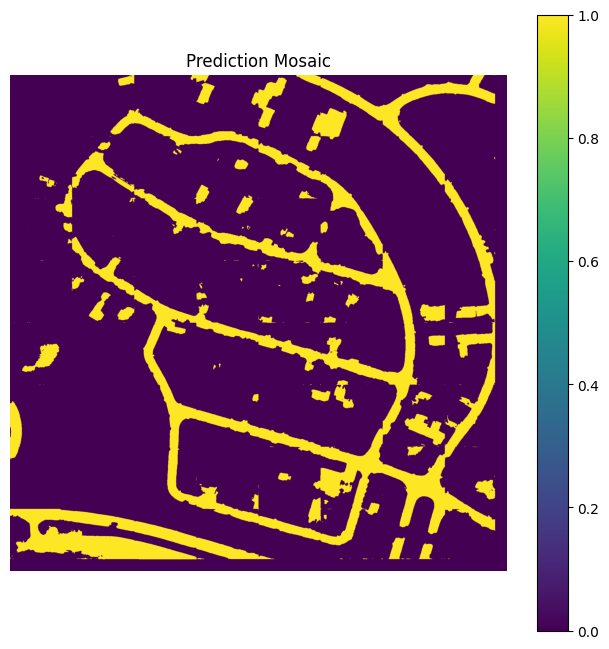

In [ ]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open('prediction_merge.tif') as src:
    img = src.read(1)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.colorbar()
plt.title('Prediction Mosaic')
plt.axis('off')